# Experiment: ASR on MINDS-14

Starter notebook for speech-to-text transcription with the MINDS-14 dataset.
The flow is:

1. Inspect the raw dataset
2. Run focused EDA on audio and text
3. Preprocess audio/text for ASR
4. Set up a pretrained baseline
5. Evaluate with WER / CER


## Project goal

Fine-tune a pretrained speech-to-text model on MINDS-14 and evaluate the transcription quality on a held-out split.

If your local copy of MINDS-14 does not contain transcript text, stop here and confirm the dataset variant before training.


In [1]:
# Install these only if your environment does not already have them.
%pip install -q datasets transformers evaluate jiwer accelerate soundfile librosa matplotlib seaborn pandas numpy


Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import io
import re
from collections import Counter
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
from datasets import Audio, load_dataset
from IPython.display import Audio as IPythonAudio, display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

print("Imports ready")


Imports ready


In [3]:
# Adjust this if you want another locale from MINDS-14.
DATASET_NAME = "PolyAI/minds14"
DATASET_CONFIG = "en-US"  # change to the locale you are using
TARGET_SAMPLING_RATE = 16000
RANDOM_SEED = 42

# Download (if not cached) or load MINDS-14 from Hugging Face Hub.
raw_dataset = load_dataset(DATASET_NAME, DATASET_CONFIG)
raw_dataset


DatasetDict({
    train: Dataset({
        features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
        num_rows: 563
    })
})

In [4]:
for split_name, split_ds in raw_dataset.items():
    print(f"Split: {split_name}")
    print(f"  Rows: {len(split_ds)}")
    print(f"  Columns: {split_ds.column_names}")
    print(f"  Features: {split_ds.features}")
    print()


Split: train
  Rows: 563
  Columns: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id']
  Features: {'path': Value('string'), 'audio': Audio(sampling_rate=8000, decode=True, num_channels=None, stream_index=None), 'transcription': Value('string'), 'english_transcription': Value('string'), 'intent_class': ClassLabel(names=['abroad', 'address', 'app_error', 'atm_limit', 'balance', 'business_loan', 'card_issues', 'cash_deposit', 'direct_debit', 'freeze', 'high_value_payment', 'joint_account', 'latest_transactions', 'pay_bill']), 'lang_id': ClassLabel(names=['cs-CZ', 'de-DE', 'en-AU', 'en-GB', 'en-US', 'es-ES', 'fr-FR', 'it-IT', 'ko-KR', 'nl-NL', 'pl-PL', 'pt-PT', 'ru-RU', 'zh-CN'])}



In [5]:
def detect_column(column_names, candidates):
    for candidate in candidates:
        if candidate in column_names:
            return candidate
    return None

train_columns = raw_dataset["train"].column_names
audio_col = detect_column(train_columns, ["audio", "speech", "waveform", "path"])
text_col = detect_column(train_columns, ["text", "transcription", "transcript", "sentence", "utterance", "normalized_text"])

print("Detected audio column:", audio_col)
print("Detected text column:", text_col)

if audio_col is None or text_col is None:
    raise ValueError(
        "Could not infer the audio/text columns automatically. "
        f"Available columns: {train_columns}"
    )

# Keep audio entries as metadata/path to avoid torchcodec decoding at row access time.
raw_dataset = raw_dataset.cast_column(audio_col, Audio(decode=False))
print("Configured audio column with decode=False")

def load_audio_record(audio_record, target_sr=None):
    path = audio_record.get("path")
    audio_bytes = audio_record.get("bytes")

    # MINDS-14 often provides valid bytes while path may be a non-resolvable filename.
    if audio_bytes is not None:
        waveform, sr = sf.read(io.BytesIO(audio_bytes))
    elif path:
        waveform, sr = sf.read(path)
    else:
        raise ValueError("Audio record has neither 'path' nor 'bytes'.")

    if waveform.ndim > 1:
        waveform = np.mean(waveform, axis=1)

    waveform = waveform.astype(np.float32)
    if target_sr is not None and sr != target_sr:
        waveform = librosa.resample(waveform, orig_sr=sr, target_sr=target_sr)
        sr = target_sr

    return waveform, sr


Detected audio column: audio
Detected text column: transcription
Configured audio column with decode=False


In [20]:
sample = raw_dataset["train"][0]
sample


{'path': 'en-US~JOINT_ACCOUNT/602ba55abb1e6d0fbce92065.wav',
 'audio': {'bytes': b'RIFF\xdeR\x01\x00WAVEfmt \x12\x00\x00\x00\x07\x00\x01\x00@\x1f\x00\x00@\x1f\x00\x00\x01\x00\x08\x00\x00\x00fact\x04\x00\x00\x00\xabR\x01\x00data\xabR\x01\x00\xff\xfe~\xff~\xff\xfe\xff\xff\xff\xff\xff\xfe\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xfe~\xff\xff\xff\xff\xff\xff\xff\xfe\xff~\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff~\xff\xff\xff~\xff\xff~\xff~\xff\xff\xff\xff\xfe\xfe\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff~\xff\xff\xff\xfe\xff\xff\xfe~\xff\xff\xfe\xff\xff\xfe\xff\xff\xff\xff\xff\xfe\xfe\xff\xff\xff\xff\xfe\xff\xff~\xfe\xff\xff\xff\xfe\xff\xff\xfe\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xfe\xff\xfe\xff\xff\xff\xff\xff\xff\xff\xff\xff\xfe\xff\xff\xff~\xff\xff\xff~\xff\xff\xff\xfe\xff\xfe\xfe\xfe\xff\xff\xff\xff\xff\xff\xff~\xff\xff\xff\xff\xfe\xff\xff\xfe\xff\xff\xff\xff\xff\xfe\xfe~\xff\xff\xff~\xff~\xff\xff\xff\xff\xff\xfe\xff\xfe\xff\xff~\xfe\xff~\xfe\xff\

In [21]:
audio_sample = sample[audio_col]
text_sample = sample[text_col]

audio_array, audio_sr = load_audio_record(audio_sample)

print("Transcript:")
print(text_sample)
print()
print("Audio metadata:")
audio_metadata = {k: v for k, v in audio_sample.items() if k != "bytes"}
audio_metadata["bytes_length"] = len(audio_sample["bytes"]) if audio_sample.get("bytes") is not None else None
print(audio_metadata)

display(IPythonAudio(audio_array, rate=audio_sr))


Transcript:
I would like to set up a joint account with my partner

Audio metadata:
{'path': '602ba55abb1e6d0fbce92065.wav', 'bytes_length': 86758}


## EDA

For ASR, the most useful early checks are audio duration, sample rate consistency, transcript length, and obvious text cleanup issues.


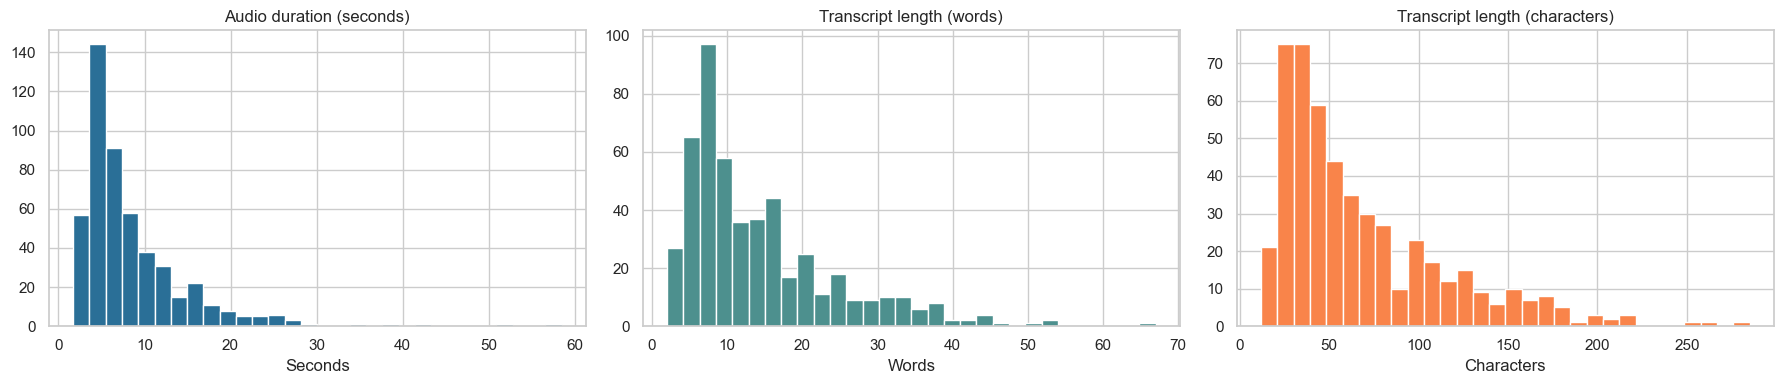

Duration summary
count    500.000000
mean       8.528764
std        6.460446
min        1.706625
25%        4.437375
50%        6.357313
75%       10.261344
max       58.453375
dtype: float64


In [8]:
eda_split = raw_dataset["train"]
eda_n = min(500, len(eda_split))
eda_subset = eda_split.select(range(eda_n))

durations = []
word_counts = []
char_counts = []

for row in eda_subset:
    audio_array, audio_sr = load_audio_record(row[audio_col], target_sr=TARGET_SAMPLING_RATE)
    durations.append(len(audio_array) / audio_sr)
    word_counts.append(len(str(row[text_col]).split()))
    char_counts.append(len(str(row[text_col])))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(durations, bins=30, color="#2a6f97")
axes[0].set_title("Audio duration (seconds)")
axes[0].set_xlabel("Seconds")

axes[1].hist(word_counts, bins=30, color="#4d908e")
axes[1].set_title("Transcript length (words)")
axes[1].set_xlabel("Words")

axes[2].hist(char_counts, bins=30, color="#f9844a")
axes[2].set_title("Transcript length (characters)")
axes[2].set_xlabel("Characters")

plt.tight_layout()
plt.show()

print("Duration summary")
print(pd.Series(durations).describe())


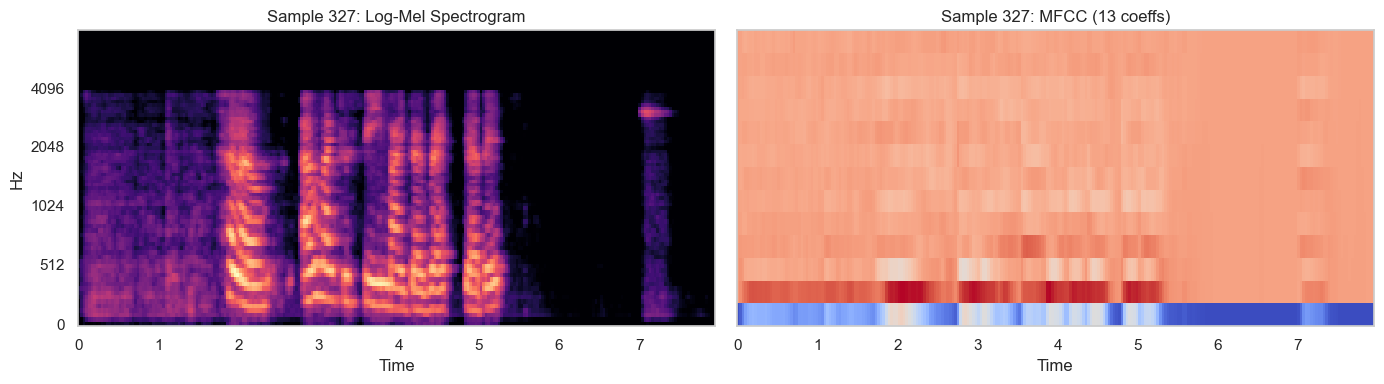

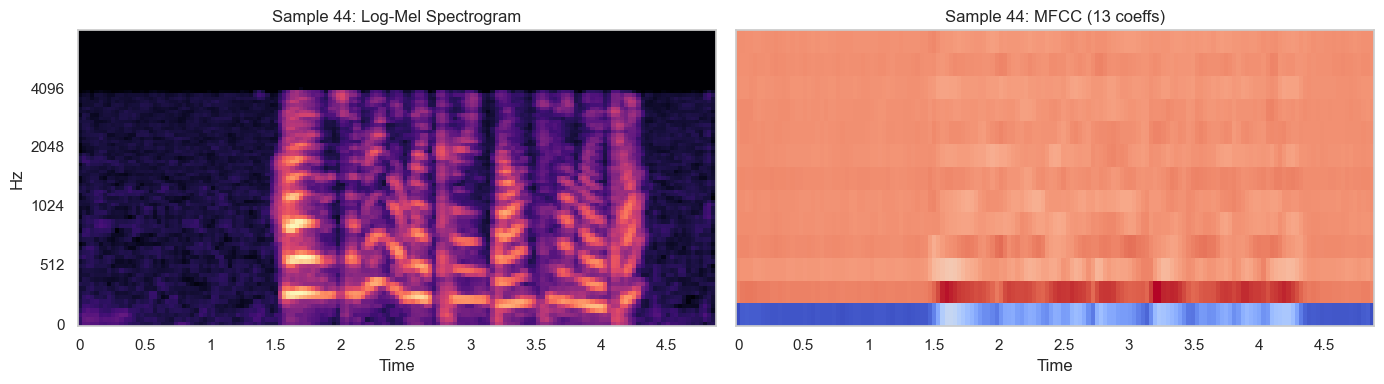

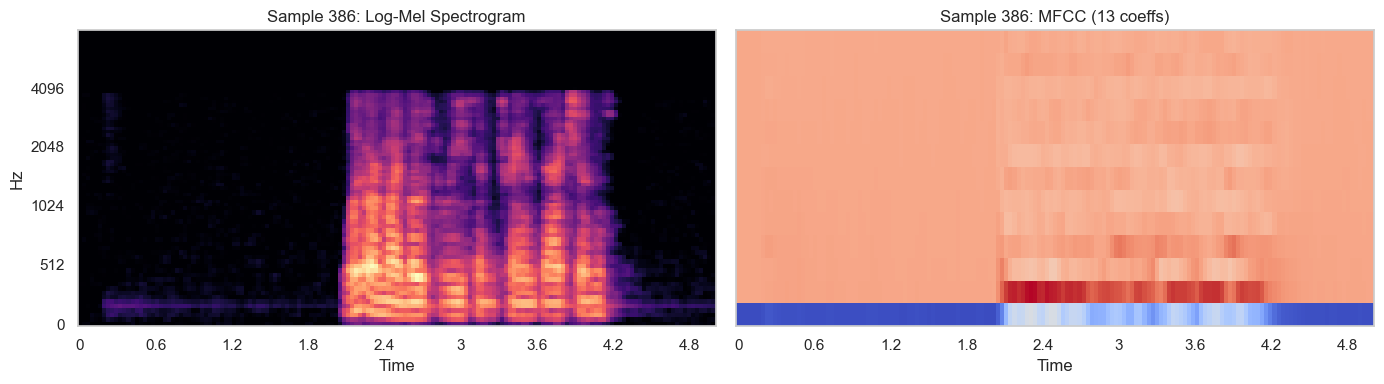

In [9]:
# Spectrogram + MFCC spot-check on a few random samples.
rng = np.random.default_rng(RANDOM_SEED)
sample_count = min(3, len(eda_subset))
random_ids = rng.choice(len(eda_subset), size=sample_count, replace=False)

for idx in random_ids:
    row = eda_subset[int(idx)]
    audio_array, audio_sr = load_audio_record(row[audio_col], target_sr=TARGET_SAMPLING_RATE)

    # Log-mel spectrogram.
    mel = librosa.feature.melspectrogram(y=audio_array, sr=audio_sr, n_mels=80)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # MFCC from log-mel style representation.
    mfcc = librosa.feature.mfcc(y=audio_array, sr=audio_sr, n_mfcc=13)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    librosa.display.specshow(mel_db, sr=audio_sr, x_axis="time", y_axis="mel", ax=axes[0])
    axes[0].set_title(f"Sample {idx}: Log-Mel Spectrogram")

    librosa.display.specshow(mfcc, sr=audio_sr, x_axis="time", ax=axes[1])
    axes[1].set_title(f"Sample {idx}: MFCC (13 coeffs)")

    plt.tight_layout()
    plt.show()


In [10]:
def normalize_text(text):
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text

normalized_texts = [normalize_text(row[text_col]) for row in eda_subset]
token_counts = Counter()
for text in normalized_texts:
    token_counts.update(text.split())

print("Most common tokens:")
print(token_counts.most_common(20))

print("Sample normalized text:")
print(normalized_texts[0])


Most common tokens:
[('i', 462), ('to', 394), ('my', 375), ('a', 194), ('account', 162), ("i'm", 142), ('and', 135), ('the', 129), ('can', 124), ('you', 116), ('card', 109), ('me', 96), ('like', 93), ('money', 84), ('is', 83), ('how', 82), ('that', 73), ('it', 71), ('hi', 69), ('make', 68)]
Sample normalized text:
i would like to set up a joint account with my partner


## Preprocessing

This section standardizes the audio and text so they can be fed into a pretrained ASR model.

If the dataset already stores audio at 16 kHz, the resampling step will have no effect.


In [11]:
processed_dataset = raw_dataset

def _normalize_text_local(text):
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text

def prepare_example(batch):
    batch["normalized_text"] = _normalize_text_local(batch[text_col])
    return batch

processed_dataset = processed_dataset.map(prepare_example)
print("Text normalization complete. Audio is loaded on demand from path/bytes.")
processed_dataset


Text normalization complete. Audio is loaded on demand from path/bytes.


DatasetDict({
    train: Dataset({
        features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'normalized_text'],
        num_rows: 563
    })
})

In [12]:
train_split = processed_dataset["train"]
if len(processed_dataset) > 1 and "validation" in processed_dataset:
    eval_split = processed_dataset["validation"]
else:
    split_dict = train_split.train_test_split(test_size=0.1, seed=RANDOM_SEED)
    train_split = split_dict["train"]
    eval_split = split_dict["test"]

print("Train rows:", len(train_split))
print("Eval rows:", len(eval_split))


Train rows: 506
Eval rows: 57


## Baseline model

Whisper is a strong first baseline for transcription. You can swap in Wav2Vec2 later if you want a CTC-style setup instead.


In [13]:
# Uncomment the installs below if needed.
# %pip install -q transformers accelerate evaluate jiwer

from transformers import WhisperForConditionalGeneration, WhisperProcessor

MODEL_CHECKPOINT = "openai/whisper-tiny"
processor = WhisperProcessor.from_pretrained(MODEL_CHECKPOINT, language="english", task="transcribe")
model = WhisperForConditionalGeneration.from_pretrained(MODEL_CHECKPOINT)
model.config.forced_decoder_ids = None
model.config.suppress_tokens = []

print("Model and processor loaded")


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Model and processor loaded


In [14]:
def build_model_inputs(batch):
    audio_array, audio_sr = load_audio_record(batch[audio_col], target_sr=TARGET_SAMPLING_RATE)
    inputs = processor(
        audio_array,
        sampling_rate=audio_sr,
    )
    labels = processor.tokenizer(batch["normalized_text"]).input_ids
    return {
        "input_features": inputs.input_features[0],
        "labels": labels,
    }

# Example transform on one row so you can verify the shapes before training.
preview = build_model_inputs(train_split[0])
print(preview.keys())
print(np.array(preview["input_features"]).shape)
print(len(preview["labels"]))


dict_keys(['input_features', 'labels'])
(80, 3000)
7


## Evaluation

Use WER as the main metric for transcription quality. CER is also useful when the transcript formatting is noisy or when the language has tokenization edge cases.


In [15]:
import evaluate

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

# After generating predictions, fill these lists and compute the metrics below.
predictions = ["replace with decoded model output"]
references = ["replace with ground truth text"]

print("WER:", wer_metric.compute(predictions=predictions, references=references))
print("CER:", cer_metric.compute(predictions=predictions, references=references))


WER: 0.6
CER: 0.4666666666666667


## Next steps

- Replace the placeholder training/evaluation lists with actual model predictions
- Add `Seq2SeqTrainer` or a custom training loop
- Log the best checkpoint and compare against a simple baseline
- Write up findings, limits, and error cases for the final portfolio report
